# Aromas piloto 2026 — captura A+B completa asumida

## tl;dr

Este notebook prueba explícitamente el contrato de diseño `eta_AB = 1`. La eficiencia física no se estima: toda masa que abandona el estado de línea se asigna al condensado combinado A+B. La validación leave-one-run-out determina si producción, partición de Mouret/Morakul y captura completa son conjuntamente compatibles con los datos.

## Contexto y métodos

### Supuestos clave

- A y B se observan químicamente como un único `MIX`; sólo sus volúmenes están separados.
- La captura total A+B se fija en 1 por supuesto de diseño, no por medición.
- La volatilización usa el equilibrio `K(E,T)·QCO2` de Morakul/Mouret.
- El condensado participa en el ajuste como medición de toda la pérdida gaseosa bajo este contrato.
- La validación deja fuera una fermentación completa por fold.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'fermentation_model').exists():
    ROOT = ROOT.parents[1]
sys.path.insert(0, str(ROOT / 'fermentation_model'))
from pilot_2026 import run_aroma_assumed_complete_capture_validation_2026 as analysis

result = analysis.load_results()
print('Resultados:', analysis.RESULTS_DIR.relative_to(ROOT))
print('Veredicto:', result['gate']['verdict'])
print('Modelo diagnóstico:', result['gate']['diagnostic_best_model'])

Resultados: fermentation_model\pilot_2026\results\aroma_assumed_complete_capture_validation_2026
Veredicto: NO_VALID_MODEL
Modelo diagnóstico: assumed_complete_capture_line_reservoir


## Resultados

,analysis_policy,model_variant,species,domain,n_observed_scored,observed_mean,rmse,nrmse_over_mean,mae,bias
4,primary,assumed_complete_capture_delayed_response,ethyl_octanoate,wine,33,75.0941,50.8868,0.6776,40.8124,-36.9007
5,primary,assumed_complete_capture_delayed_response,isoamyl_acetate,wine,33,1026.5980,997.3096,0.9715,834.3384,-834.3384
6,primary,assumed_complete_capture_delayed_response_plus...,ethyl_octanoate,wine,33,75.0941,44.9758,0.5989,34.1932,-28.7881
7,primary,assumed_complete_capture_delayed_response_plus...,isoamyl_acetate,wine,33,1026.5980,887.5065,0.8645,698.9739,-680.2549
8,primary,assumed_complete_capture_equilibrium,ethyl_octanoate,wine,33,75.0941,73.8790,0.9838,65.4933,-65.4933
9,primary,assumed_complete_capture_equilibrium,isoamyl_acetate,wine,33,1026.5980,1126.0155,1.0968,987.6411,-987.6411
10,primary,assumed_complete_capture_line_reservoir,ethyl_octanoate,wine,33,75.0941,54.2609,0.7226,44.6837,-44.3381
11,primary,assumed_complete_capture_line_reservoir,isoamyl_acetate,wine,33,1026.5980,1035.3985,1.0086,892.1484,-892.1484
16,primary,assumed_complete_capture_delayed_response,ethyl_octanoate,condensate,19,395.7461,581.2860,1.4688,386.6713,182.8094
17,primary,assumed_complete_capture_delayed_response,isoamyl_acetate,condensate,13,1697.7617,1634.6802,0.9628,1231.0217,-170.1208


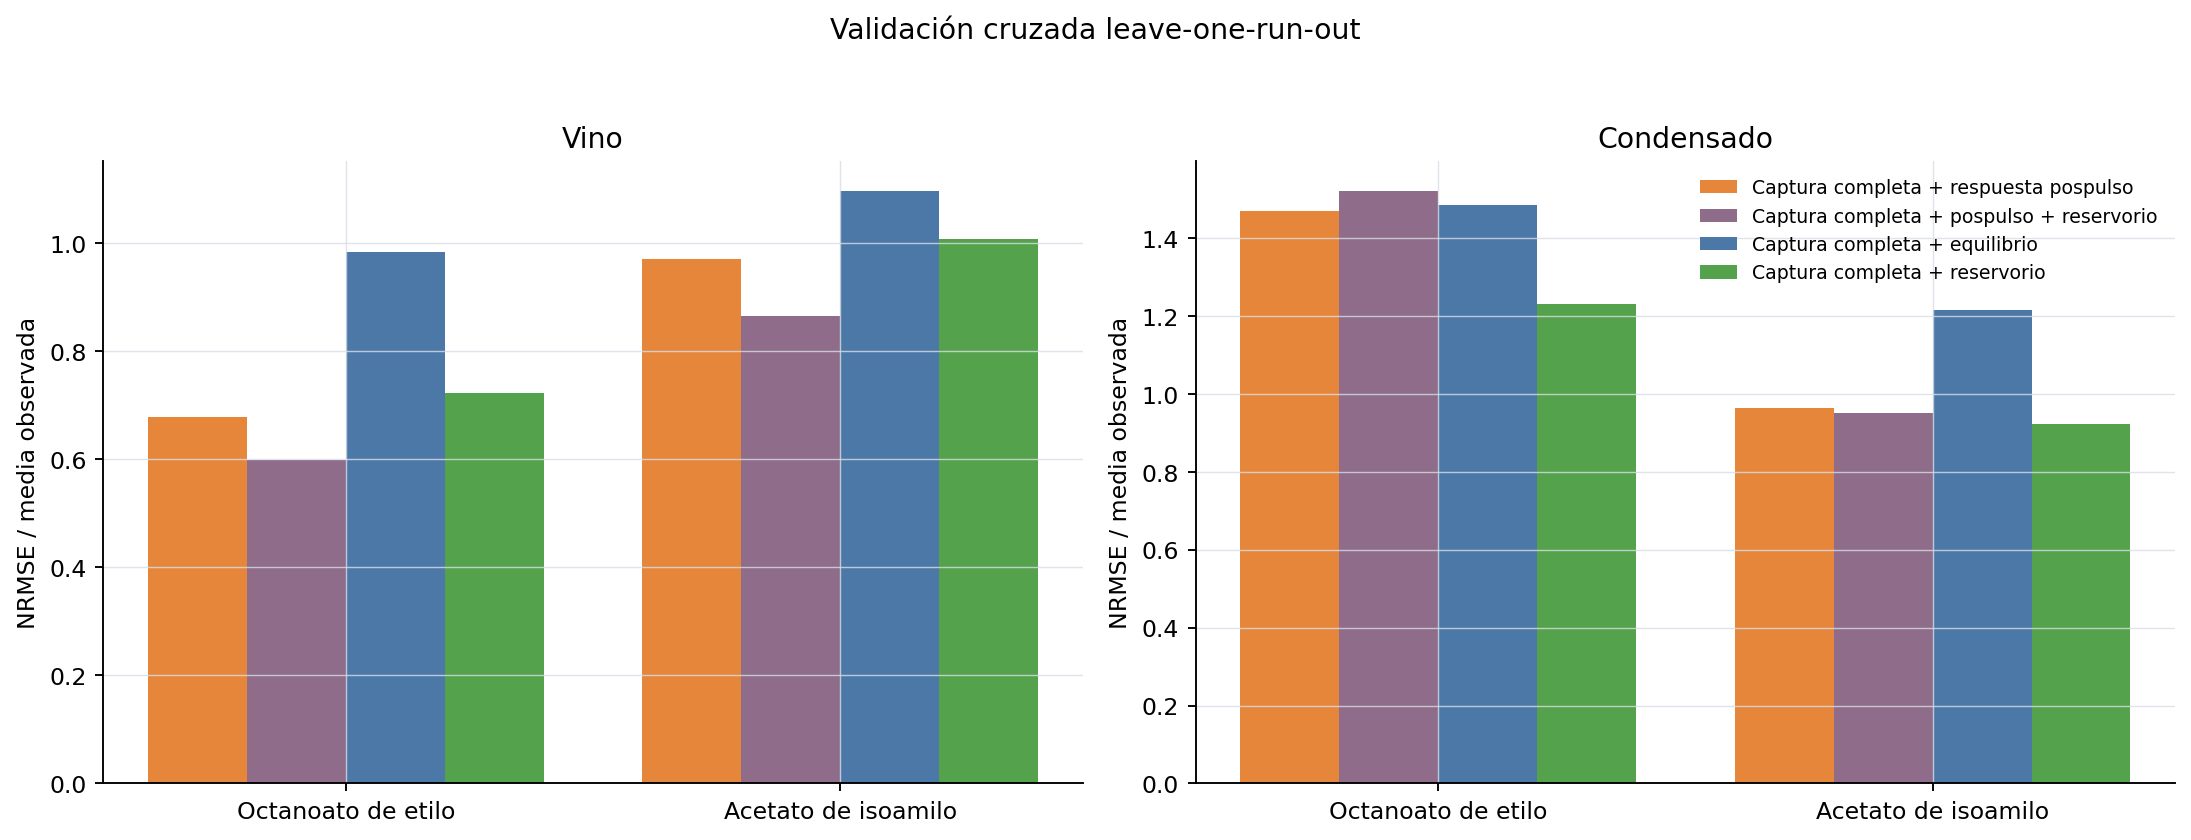

In [2]:
primary_metrics = result['metrics'].query("analysis_policy == 'primary'")
display(primary_metrics.round(4))
display(Image(filename=analysis.FIGURE_DIR / '02_loro_nrmse_comparison.png'))

In [3]:
display(result['capture_audit'])
display(result['previous_comparison'].round(4))
display(result['parameters'].round(5))

,contract,fixed_total_capture_fraction,minimum_simulated_capture_fraction,maximum_simulated_capture_fraction,maximum_absolute_unrecovered_ug,maximum_absolute_mass_closure_error_ug,physical_efficiency_identified,interpretation
0,combined_A_plus_B_complete_capture,1.0,1.0,1.0,0.0,1.127773e-10,False,eta_AB=1 is imposed by design assumption; it i...


,complete_capture_model,species,domain,previous_effective_model_nrmse,complete_capture_model_nrmse,relative_nrmse_change_fraction
0,assumed_complete_capture_line_reservoir,ethyl_octanoate,wine,0.4208,0.7226,0.7173
1,assumed_complete_capture_line_reservoir,isoamyl_acetate,wine,0.4753,1.0086,1.1219
2,assumed_complete_capture_line_reservoir,ethyl_octanoate,condensate,1.1876,1.2302,0.0359
3,assumed_complete_capture_line_reservoir,isoamyl_acetate,condensate,0.9853,0.9224,-0.0639


,fit_scope,species,model_variant,parameter,estimate,lower_bound,upper_bound,active_bound,std_log_local
0,all_data,ethyl_octanoate,assumed_complete_capture_equilibrium,formation_growth_ug_per_g_sugar,0.00497,0.0001,10000.0,False,43.96203
1,all_data,ethyl_octanoate,assumed_complete_capture_equilibrium,formation_stationary_ug_per_g_sugar,0.08628,0.0001,10000.0,False,1.85260
2,all_data,isoamyl_acetate,assumed_complete_capture_equilibrium,formation_growth_ug_per_g_sugar,0.05158,0.0001,10000.0,False,32.67076
3,all_data,isoamyl_acetate,assumed_complete_capture_equilibrium,formation_stationary_ug_per_g_sugar,0.42902,0.0001,10000.0,False,1.71256
4,all_data,ethyl_octanoate,assumed_complete_capture_line_reservoir,formation_growth_ug_per_g_sugar,0.00827,0.0001,10000.0,False,33.10246
5,all_data,ethyl_octanoate,assumed_complete_capture_line_reservoir,formation_stationary_ug_per_g_sugar,0.39146,0.0001,10000.0,False,1.05503
6,all_data,ethyl_octanoate,assumed_complete_capture_line_reservoir,line_reservoir_tau_h,72.00000,0.2500,72.0,True,1.95576
7,all_data,isoamyl_acetate,assumed_complete_capture_line_reservoir,formation_growth_ug_per_g_sugar,0.10124,0.0001,10000.0,False,25.92625
8,all_data,isoamyl_acetate,assumed_complete_capture_line_reservoir,formation_stationary_ug_per_g_sugar,1.57086,0.0001,10000.0,False,2.09087
9,all_data,isoamyl_acetate,assumed_complete_capture_line_reservoir,line_reservoir_tau_h,72.00000,0.2500,72.0,True,3.39515


In [4]:
display(result['mass'].round(4))
assert result['capture_audit']['fixed_total_capture_fraction'].eq(1.0).all()
assert result['capture_audit']['minimum_simulated_capture_fraction'].eq(1.0).all()
assert result['capture_audit']['maximum_simulated_capture_fraction'].eq(1.0).all()
assert result['capture_audit']['maximum_absolute_unrecovered_ug'].max() < 1e-8
assert result['capture_audit']['maximum_absolute_mass_closure_error_ug'].max() < 1e-6

,model_variant,species,experiment_id,terminal_time_h,initial_liquid_inventory_ug,biological_production_ug,terminal_liquid_inventory_ug,terminal_line_inventory_ug,emitted_or_drained_ug,recovered_condensate_ug,emitted_but_unrecovered_ug,mass_closure_error_ug,volatile_fraction_of_available_mass,effective_recovery_fraction_of_drained_mass
0,assumed_complete_capture_delayed_response,ethyl_octanoate,26157,170.0,918.8240,11198.8892,10152.1845,0.0000,1965.5287,1965.5287,0.0,-0.0,0.1622,1.0
1,assumed_complete_capture_delayed_response,ethyl_octanoate,26158,170.0,756.9365,11345.8908,10138.3191,0.0000,1964.5081,1964.5081,0.0,0.0,0.1623,1.0
2,assumed_complete_capture_delayed_response,ethyl_octanoate,26159,211.0,844.1882,9705.5557,9294.8736,0.0000,1254.8703,1254.8703,0.0,0.0,0.1189,1.0
3,assumed_complete_capture_delayed_response,ethyl_octanoate,26210,187.0,939.0647,18634.9087,16568.3687,0.0000,3005.6047,3005.6047,0.0,0.0,0.1536,1.0
4,assumed_complete_capture_delayed_response,ethyl_octanoate,26211,187.0,648.9652,19112.3065,16814.8492,0.0000,2946.4225,2946.4225,0.0,-0.0,0.1491,1.0
5,assumed_complete_capture_delayed_response,ethyl_octanoate,26212,187.0,586.1552,23922.1334,21137.0814,0.0000,3371.2072,3371.2072,0.0,-0.0,0.1376,1.0
6,assumed_complete_capture_delayed_response,isoamyl_acetate,26157,170.0,575.0000,52211.9729,48373.8135,0.0000,4413.1594,4413.1594,0.0,-0.0,0.0836,1.0
7,assumed_complete_capture_delayed_response,isoamyl_acetate,26158,170.0,575.0000,52871.4994,48821.7714,0.0000,4624.7280,4624.7280,0.0,0.0,0.0865,1.0
8,assumed_complete_capture_delayed_response,isoamyl_acetate,26159,211.0,575.0000,45336.0312,43177.5572,0.0000,2733.4740,2733.4740,0.0,0.0,0.0595,1.0
9,assumed_complete_capture_delayed_response,isoamyl_acetate,26210,187.0,575.0000,86471.4933,80078.7775,0.0000,6967.7157,6967.7157,0.0,-0.0,0.0800,1.0


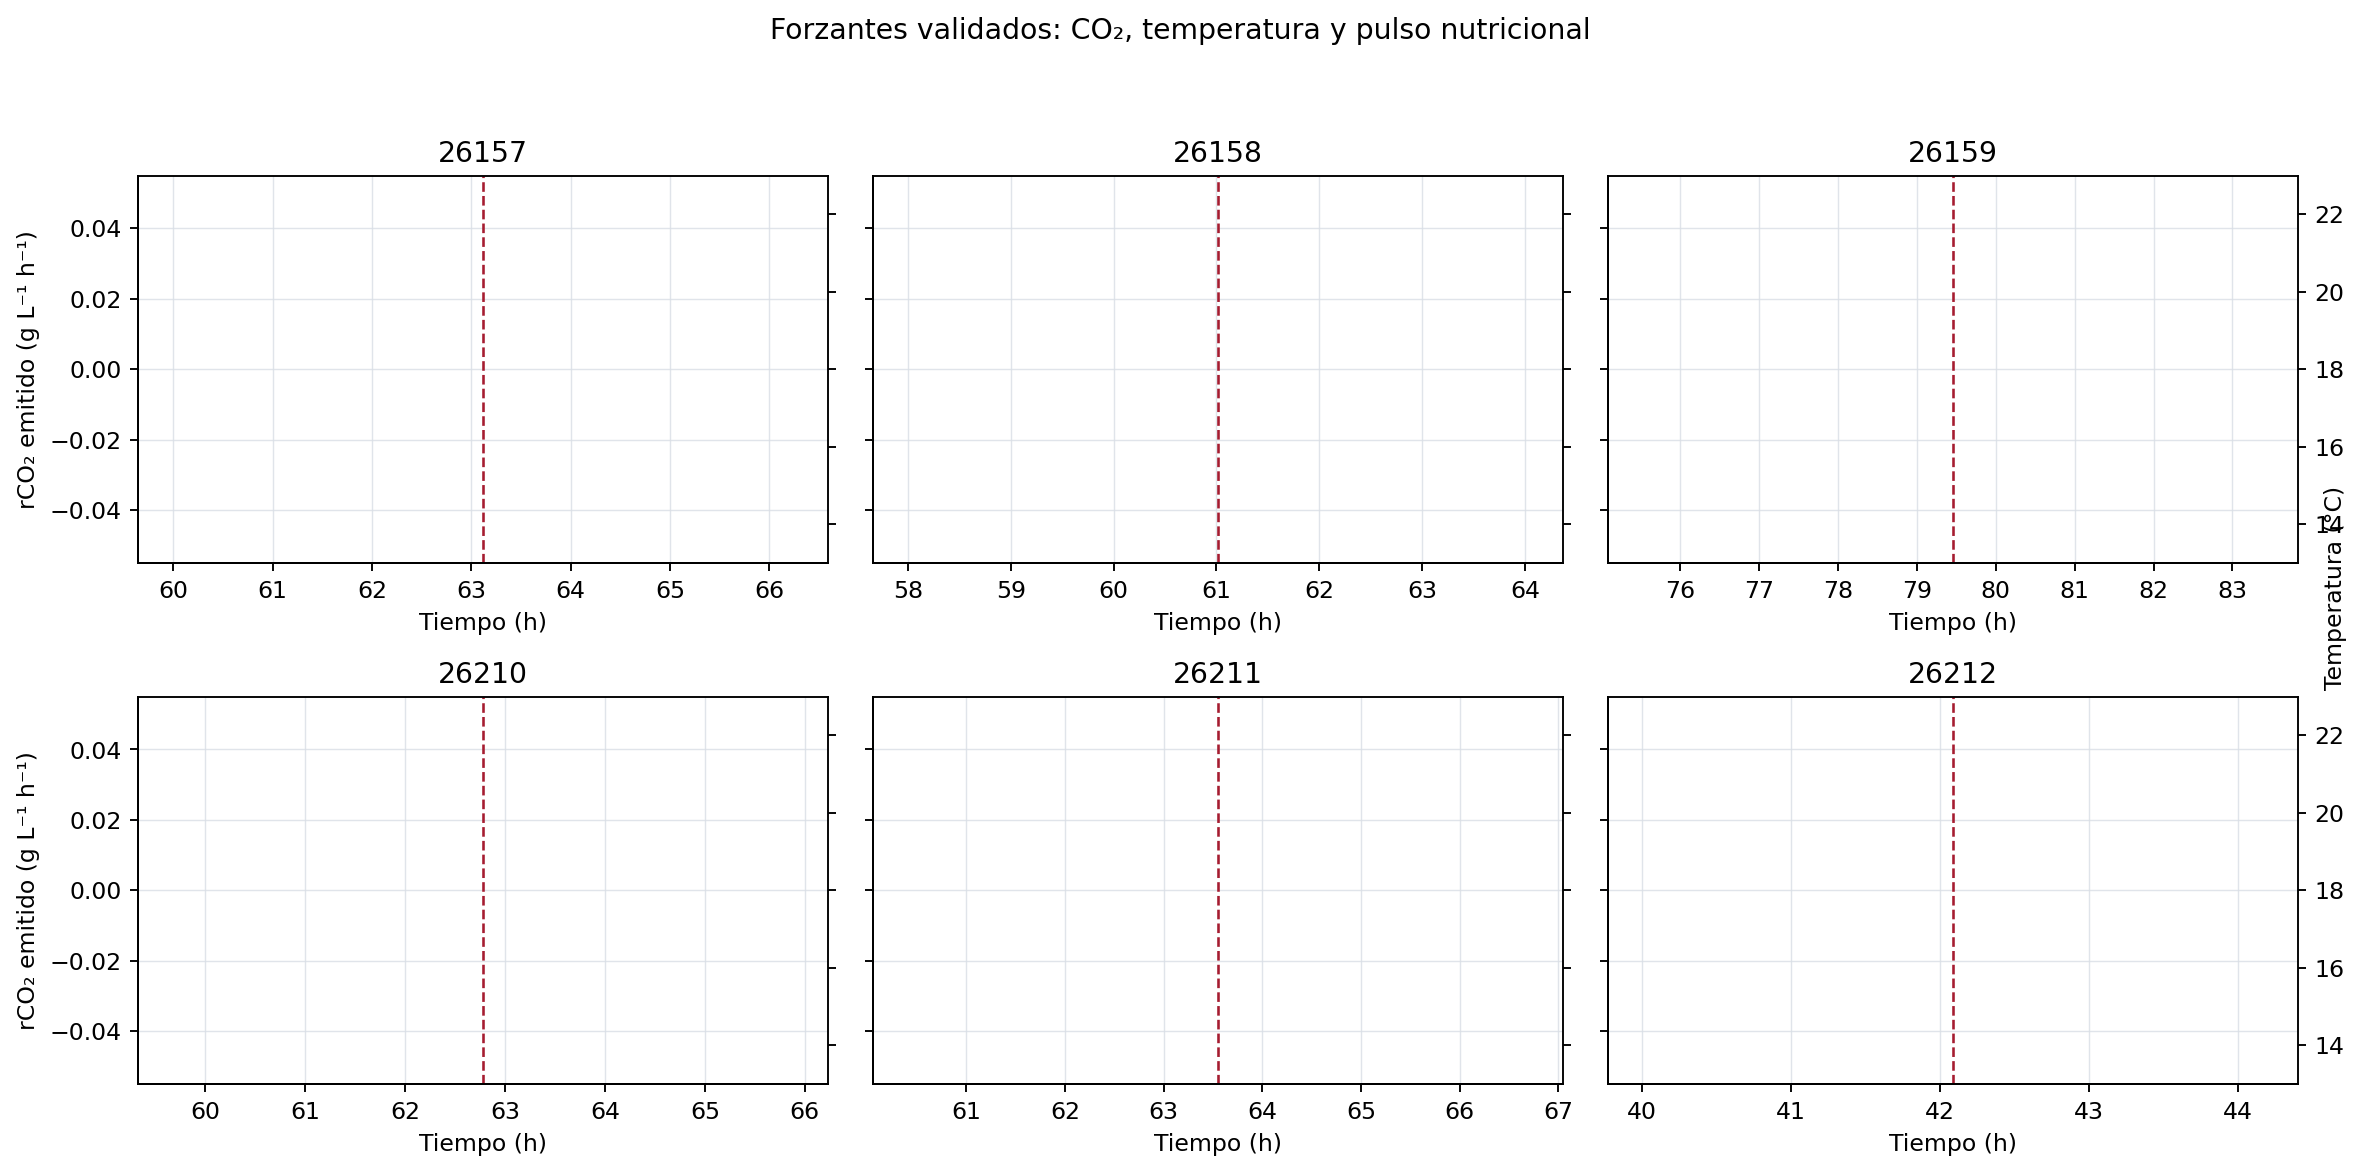

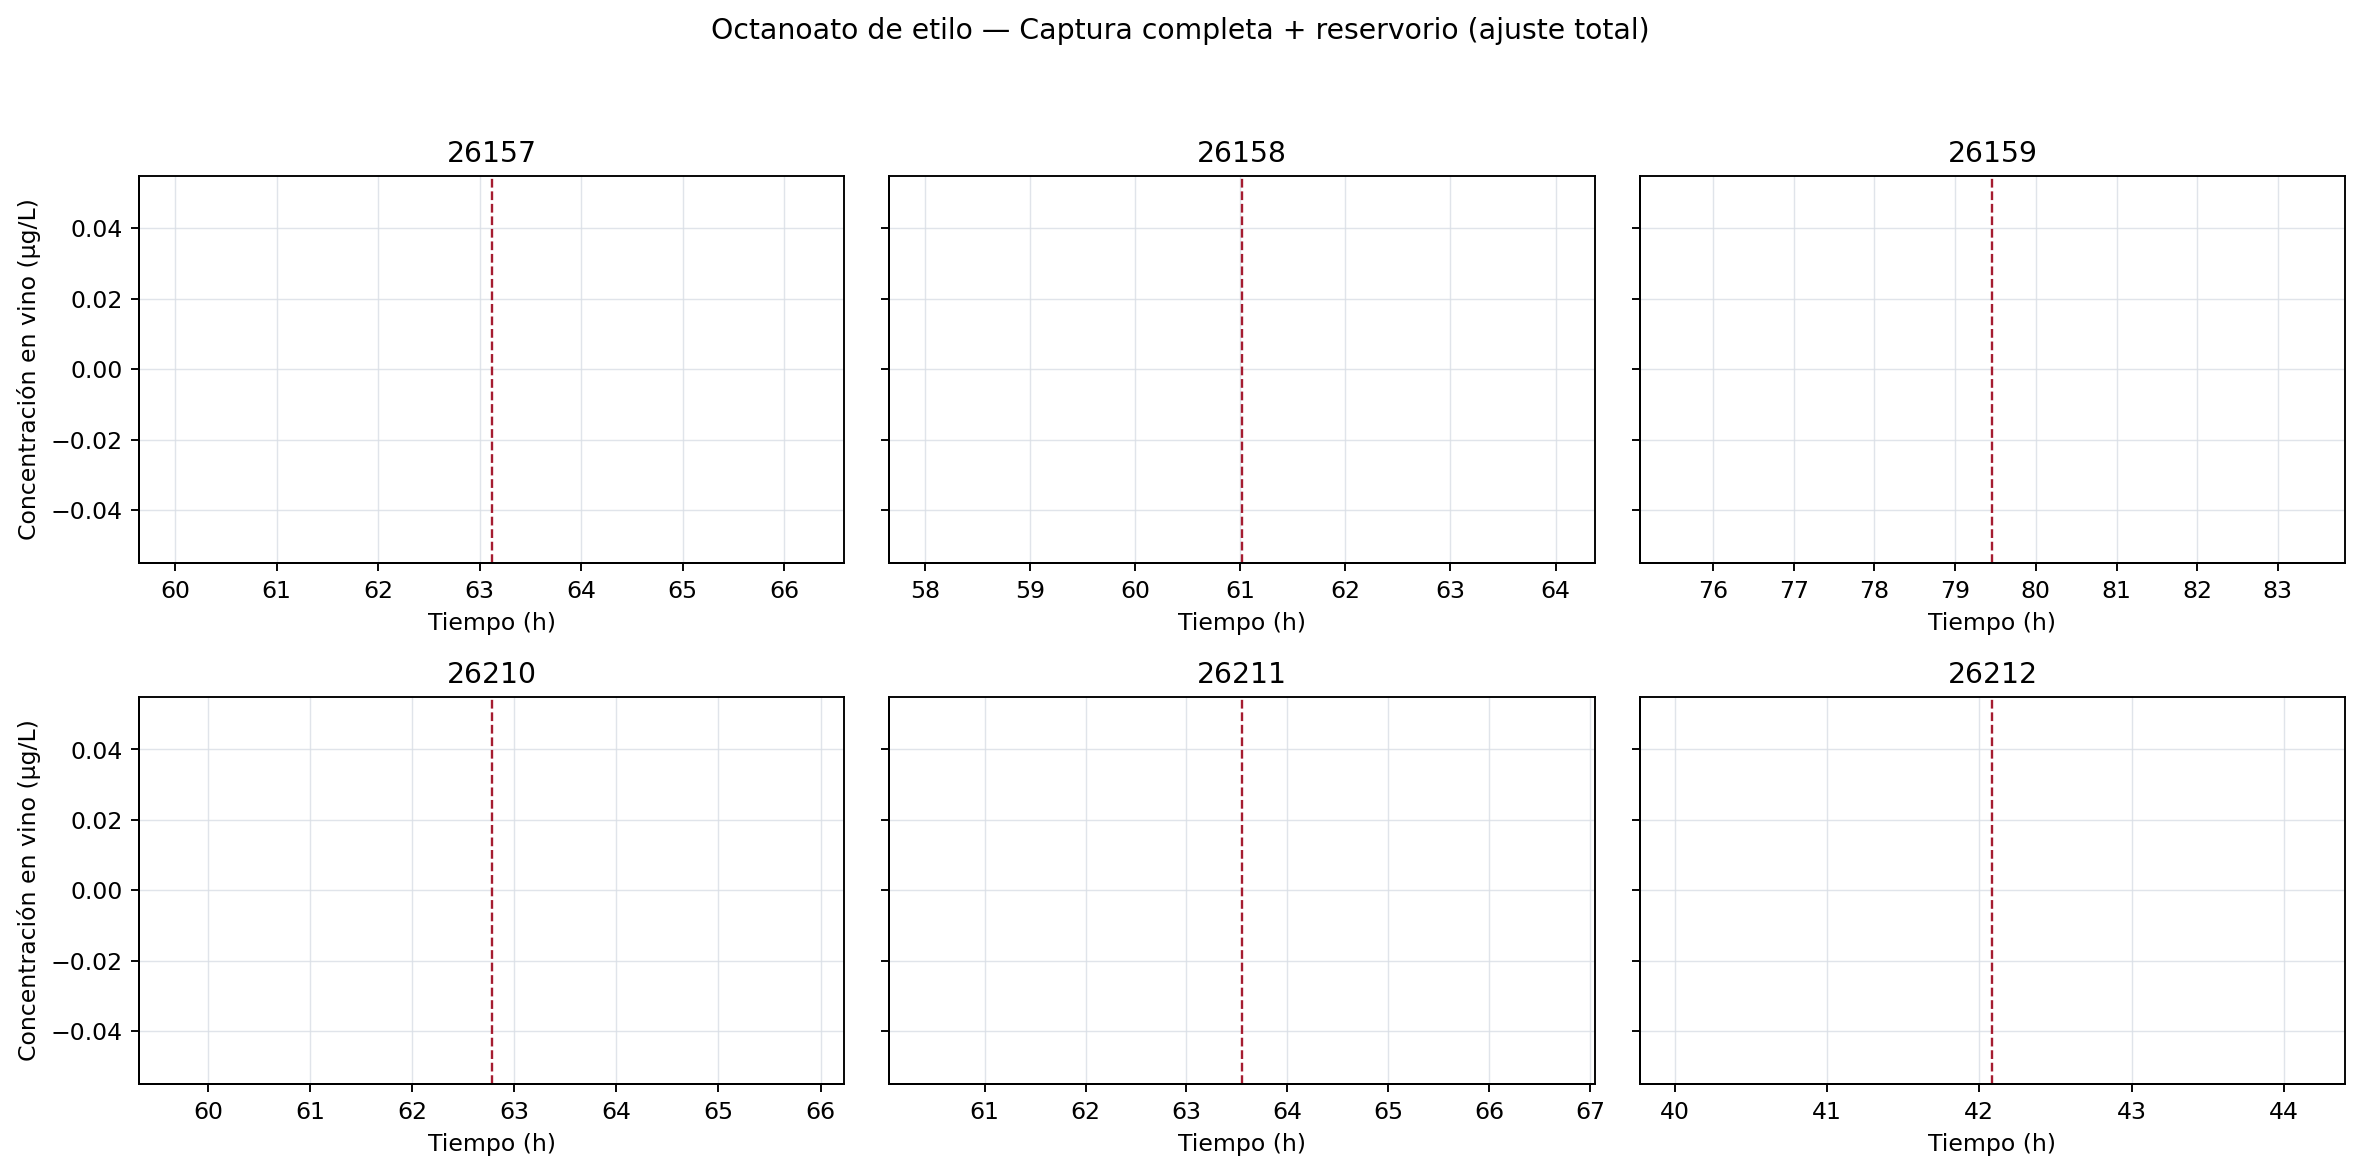

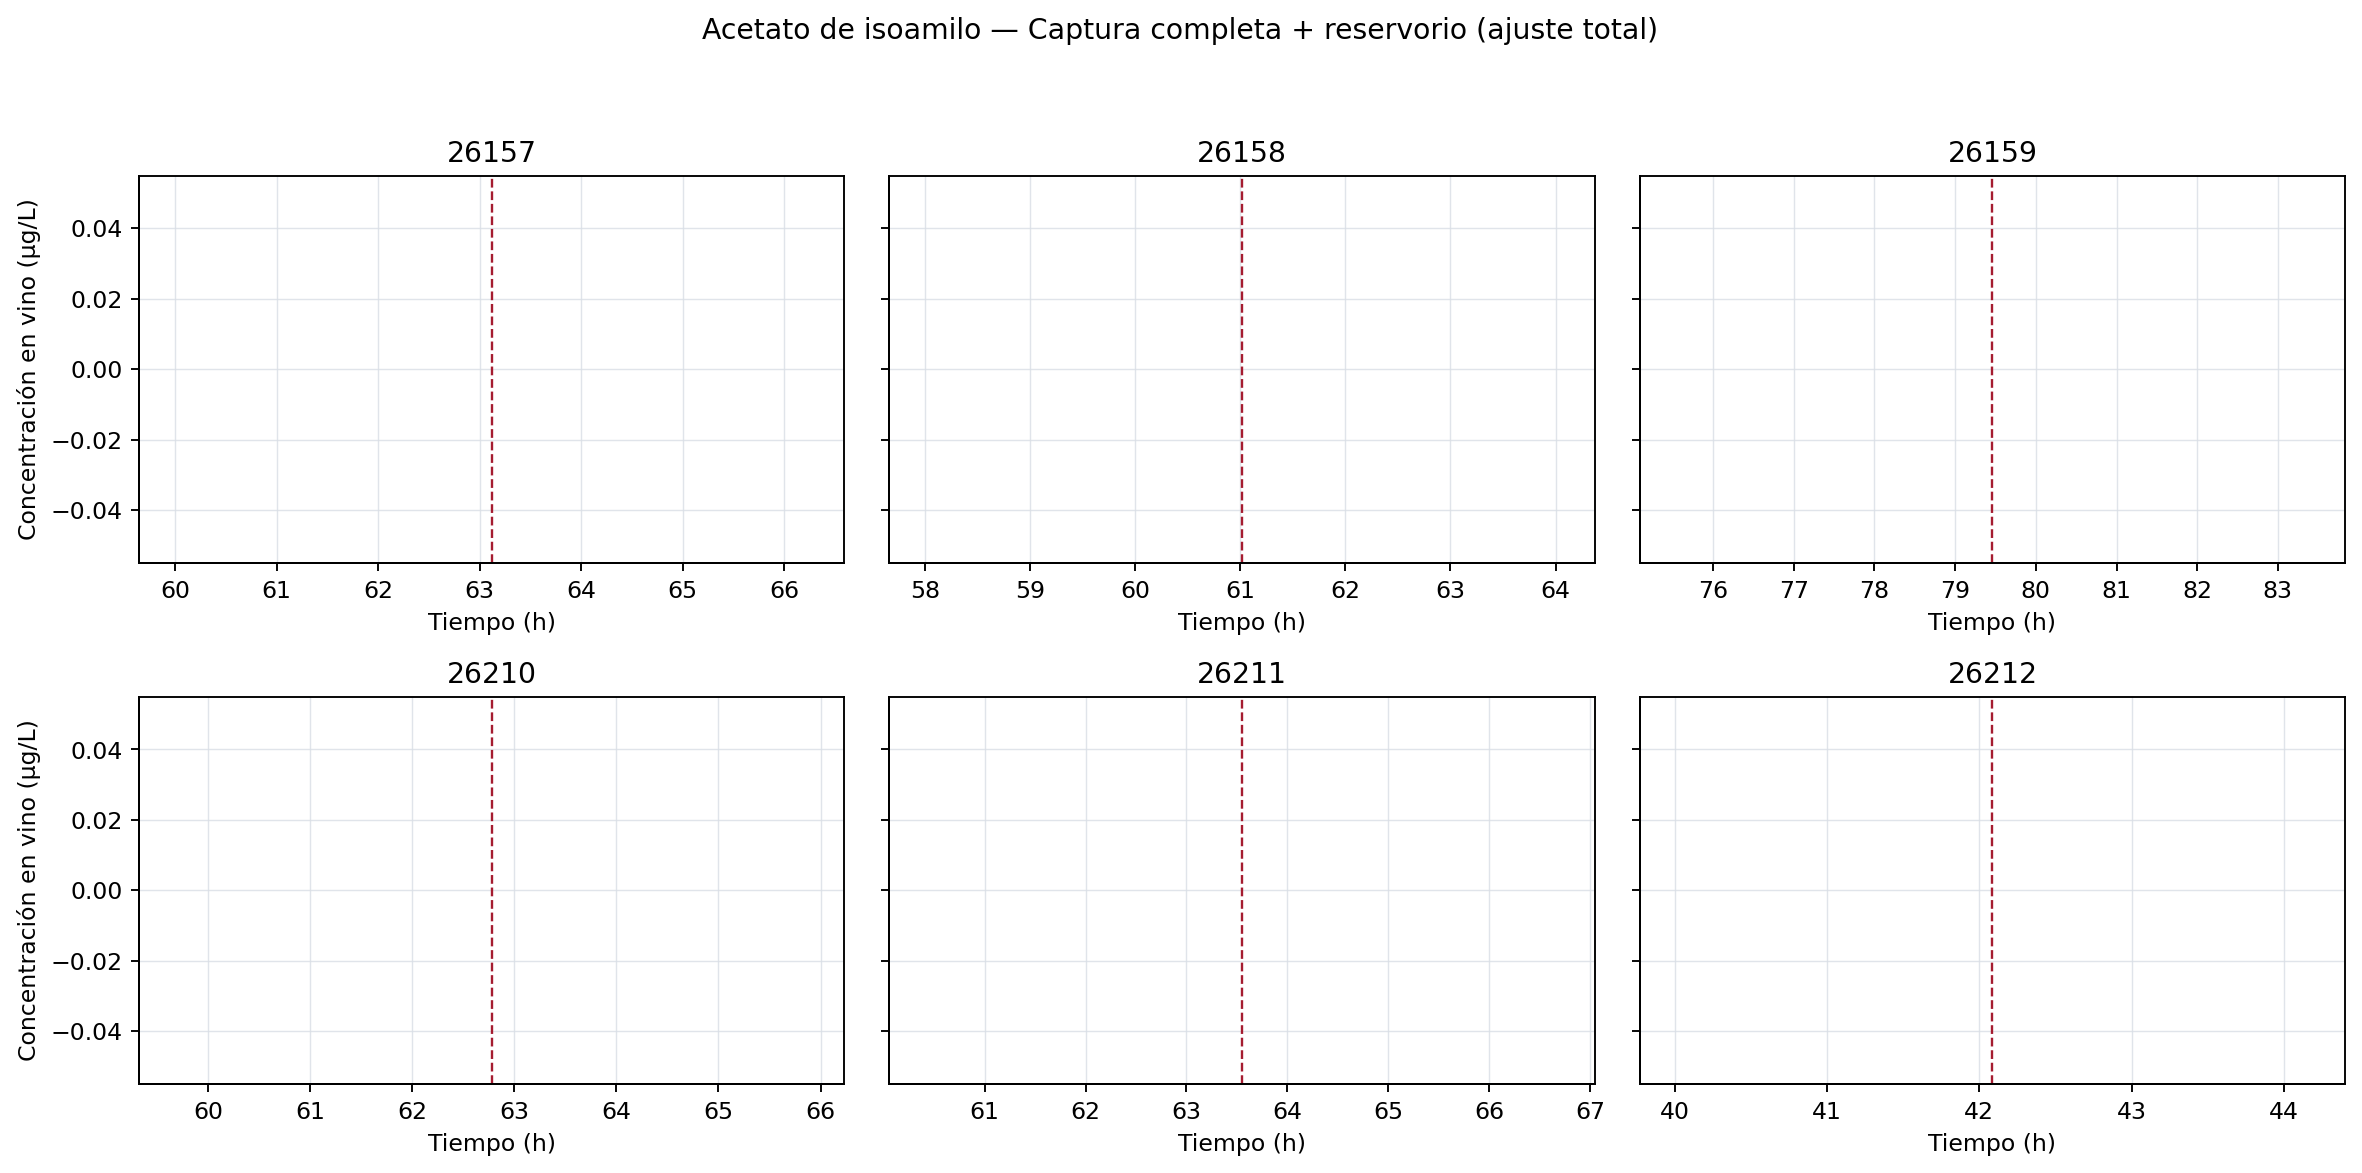

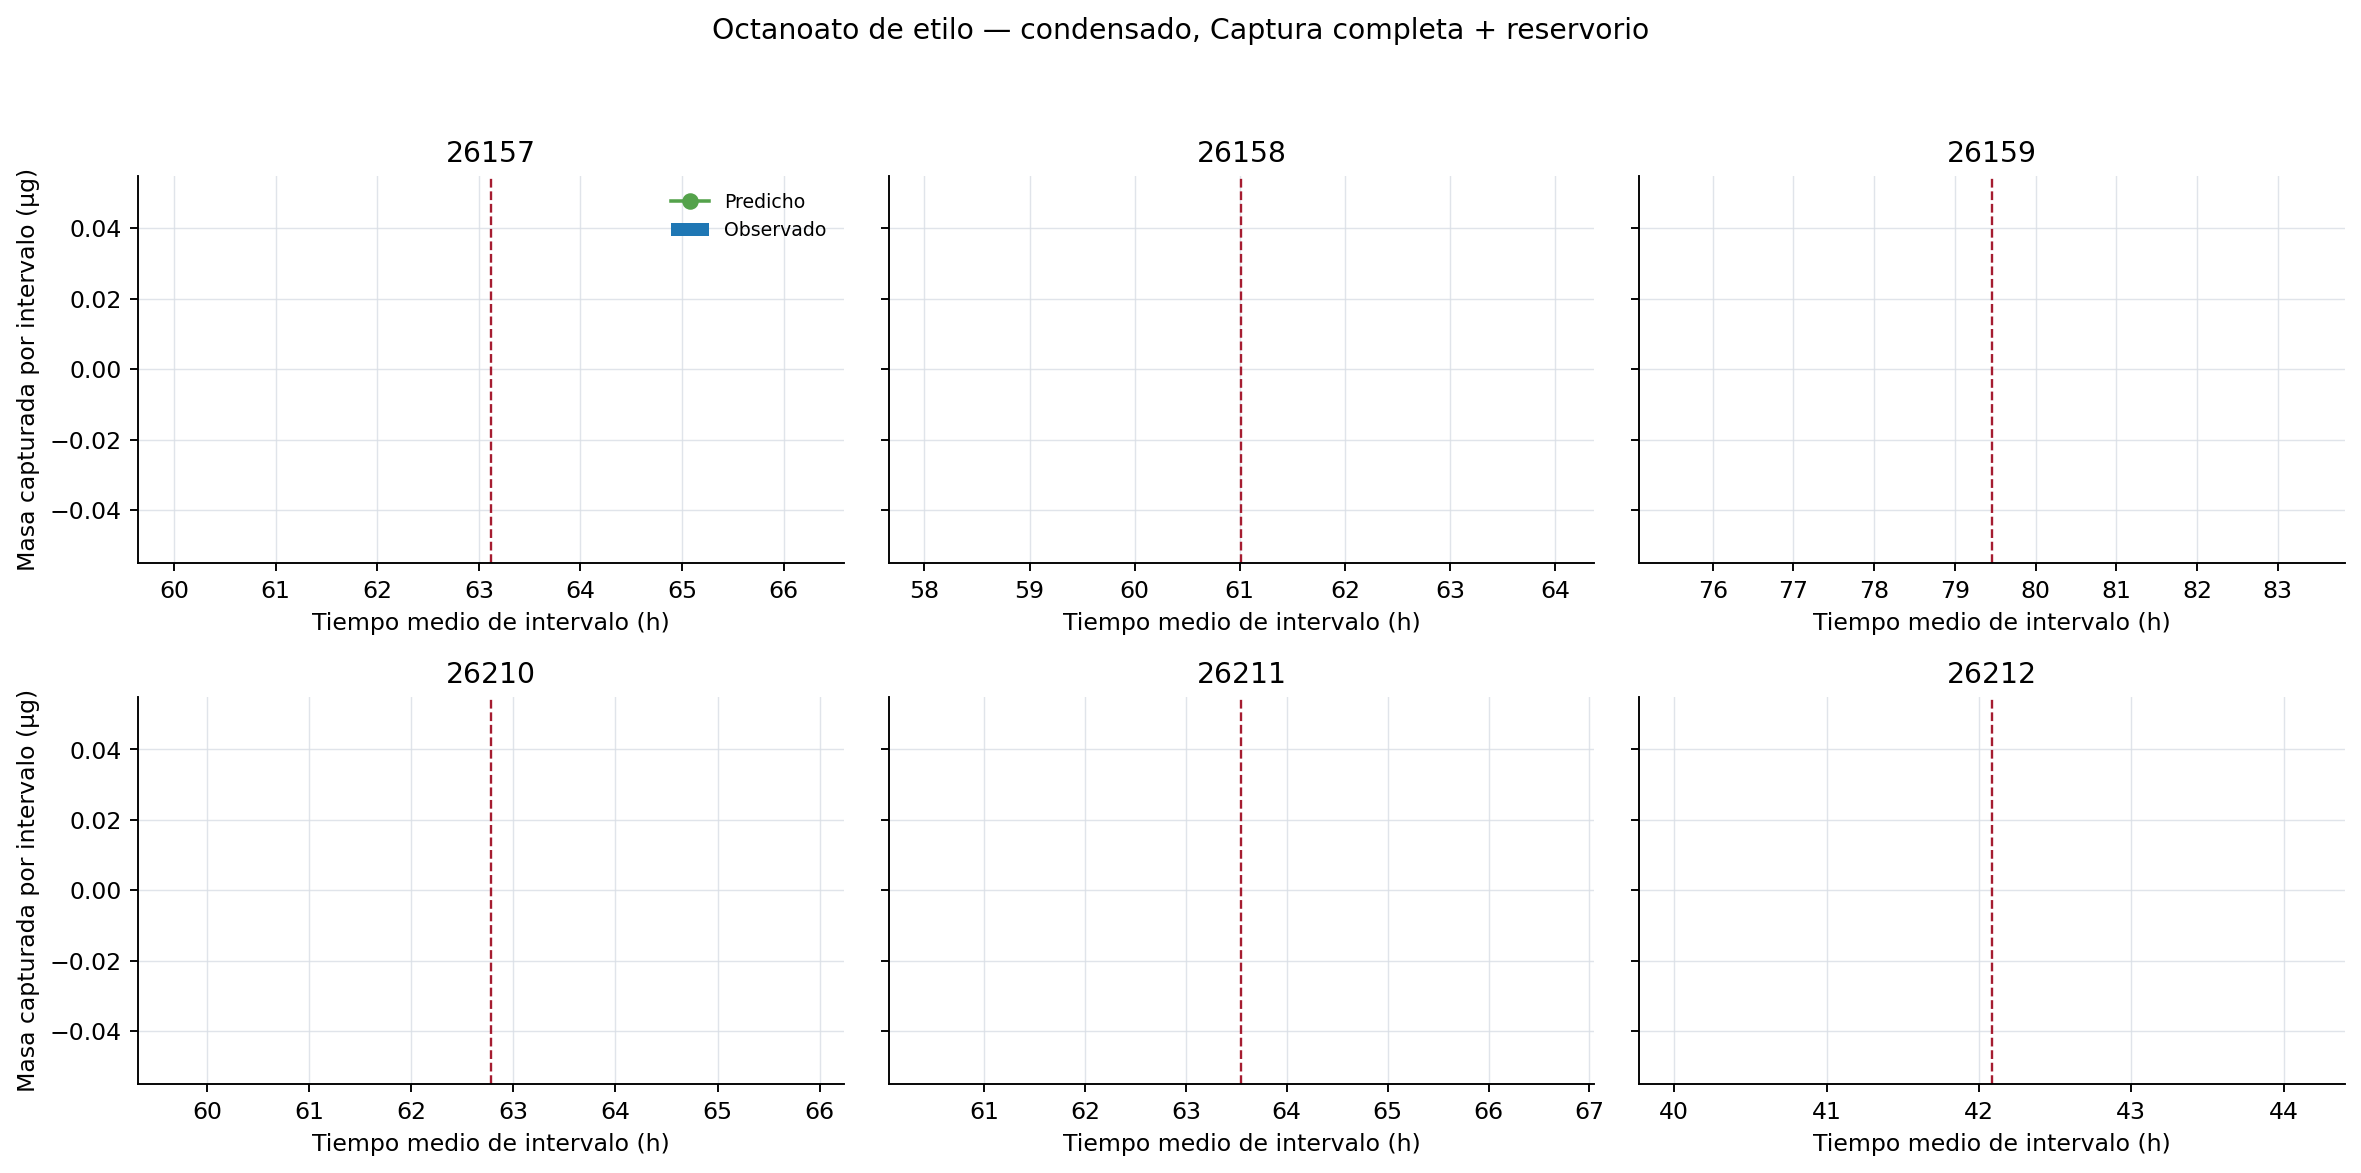

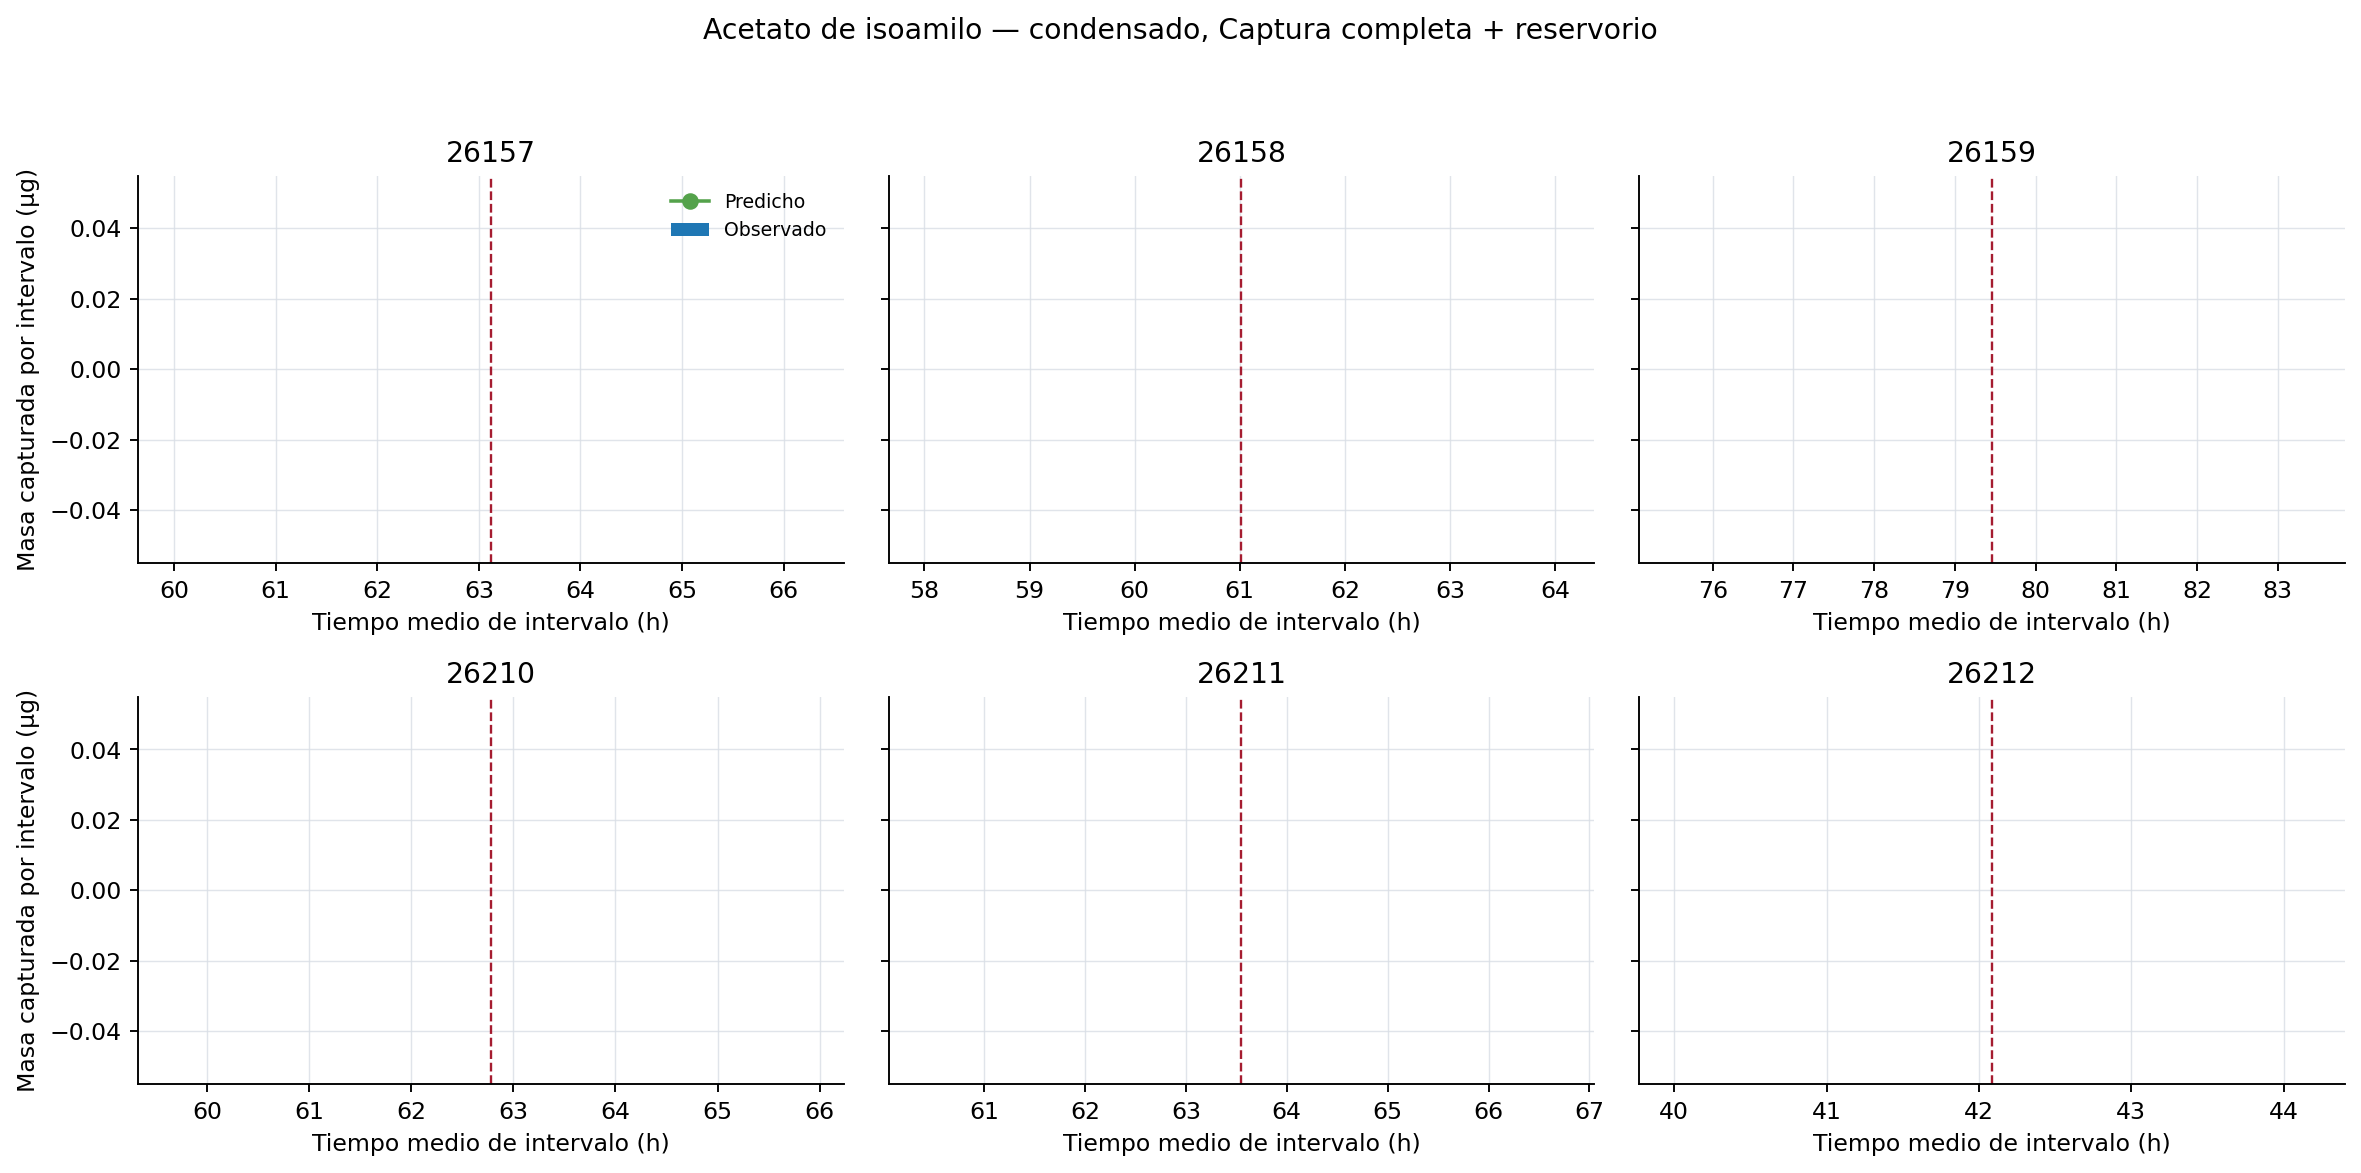

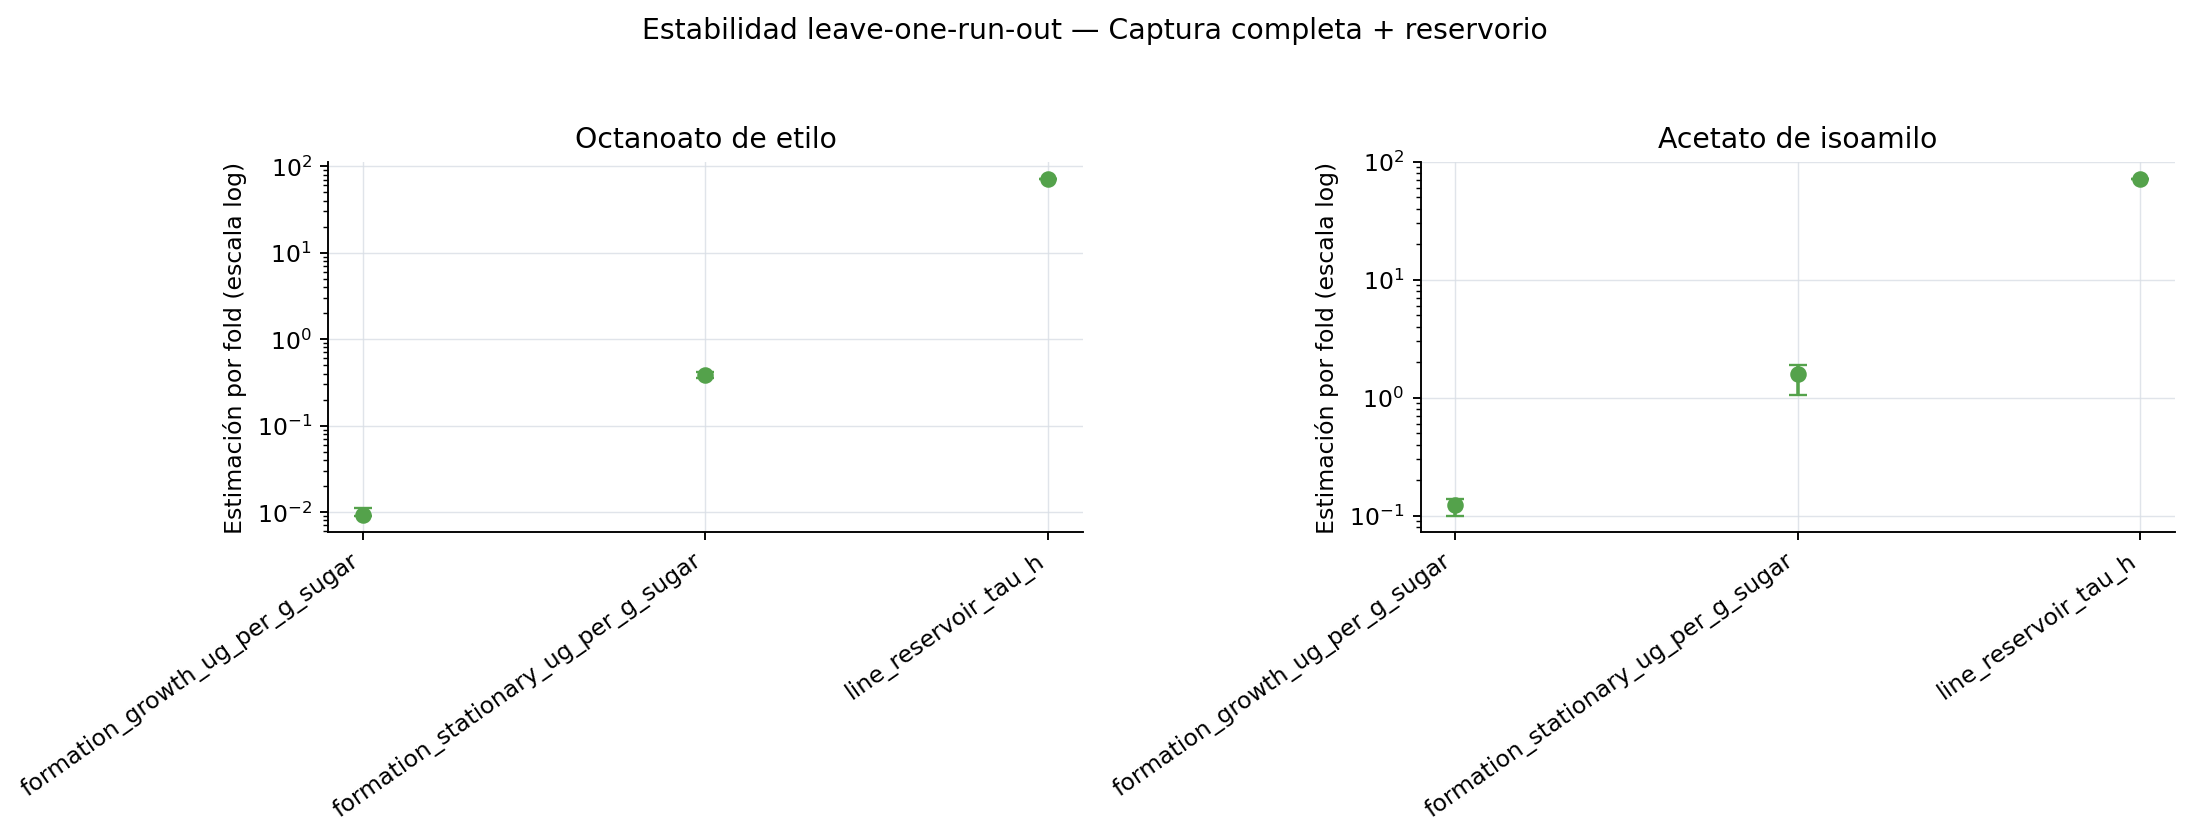

In [5]:
for name in [
    '03_rco2_temperature_pulse_drivers.png',
    '04_liquid_ethyl_octanoate.png',
    '04_liquid_isoamyl_acetate.png',
    '05_condensate_ethyl_octanoate.png',
    '05_condensate_isoamyl_acetate.png',
    '06_parameter_stability.png',
]:
    display(Image(filename=analysis.FIGURE_DIR / name))

## Conclusiones

El veredicto se interpreta sobre el contrato conjunto, no sobre la eficiencia del equipo. Si el condensado no cierra, los datos actuales no permiten asignar la discrepancia exclusivamente a producción, partición o captura completa. El resultado correcto es aceptar o rechazar la compatibilidad del supuesto, manteniéndolo visible.